# CAPTCHA Recognition using a Convolutional Recurrent Neural Network (CRNN)

## Introduction

Optical Character Recognition (OCR) is the task of automatically converting text present in images into machine-readable text. A common application of OCR is CAPTCHA recognition, where the objective is to identify and decode sequences of characters from distorted images. CAPTCHAs are designed to be easily understood by humans while being difficult for automated systems, making them an interesting benchmark for sequence recognition models.

In this project, a Convolutional Recurrent Neural Network (CRNN) is developed to recognize text from CAPTCHA images. The model combines the strengths of Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs). The CNN component extracts spatial features from the input image, capturing visual patterns such as edges, curves, and character shapes. These features are then transformed into a sequence representation and processed by stacked Bidirectional Long Short-Term Memory (BiLSTM) layers, which learn contextual dependencies between characters across the image.

Unlike traditional character-by-character classification approaches, the CRNN predicts an entire sequence of characters directly from the image. This makes it particularly suitable for text recognition tasks where character segmentation is difficult or unnecessary. The model outputs a probability distribution over possible characters at each timestep, enabling the recognition of variable-length text sequences.

The objective of this project is to train and evaluate a CRNN-based OCR system capable of accurately decoding CAPTCHA images while demonstrating the effectiveness of combining convolutional feature extraction with sequential modeling for image-based text recognition.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

import string
from tqdm.notebook import tqdm
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import multiprocessing as mp

## Dataset

The dataset consists of CAPTCHA images and their corresponding text labels. Training images are stored in the `train_images` directory, while test images are stored in `test_images`. The ground-truth labels for the training set are provided in `train-labels.csv`, which maps each image to its CAPTCHA text. The labels are loaded using Pandas, and any unnecessary index columns are removed during preprocessing to ensure a clean dataset structure.

In [2]:
data_path = "cig_ps"
test_images_path = data_path + "/test_images"
train_images_path = data_path + "/train_images"
train_labels = pd.read_csv(data_path + "/train-labels.csv")

if 'Unnamed: 0' in train_labels.columns:
    train_labels = train_labels.drop(columns=['Unnamed: 0'])

## Vocabulary Creation

To prepare the dataset for character-level recognition, a vocabulary is constructed by extracting all unique characters present in the training labels. This vocabulary defines the set of possible characters that the model can predict and is used to create mappings between characters and numerical indices required for training and inference.

In [3]:
all_text = ''.join(train_labels['text'])

vocab = sorted(set(all_text))

print("Vocabulary size:", len(vocab))
print(vocab)

Vocabulary size: 38
['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


## Data Validation and Label Correction

To ensure the quality of the training data, an exploratory analysis is performed on the CAPTCHA labels before model training. First, the distribution of label lengths is examined to verify that all CAPTCHAs contain the expected six-character sequence. The labels are also checked for invalid characters using regular expressions, ensuring that only uppercase letters (`A-Z`) and digits (`0-9`) are present.

Any labels that do not satisfy these conditions are flagged as potential errors. For each anomalous sample, the corresponding CAPTCHA image is displayed and manually inspected. This visual verification helps identify cases where labels may be incorrectly recorded, truncated, or contain unwanted characters. The labels are then corrected based on the actual text visible in the image.

This data-cleaning step is important because OCR models are highly sensitive to label quality. Even a small number of incorrect annotations can negatively affect learning, making manual validation and correction a valuable preprocessing step for improving model performance.

In [4]:
train_labels['text'].str.len().value_counts().sort_index()

text
6    19998
8        1
9        1
Name: count, dtype: int64

In [5]:
train_labels[train_labels["text"].str.len() != 6]

,image,text
2184,train-2184.png,5.40E+12
6819,train-6819.png,04-Mar-54


In [6]:
train_labels[
    train_labels["text"].str.contains(r"[^A-Z0-9]", regex=True)
]

,image,text
2184,train-2184.png,5.40E+12
6819,train-6819.png,04-Mar-54


In [7]:
bad_row = train_labels[train_labels["text"].str.contains("-", regex=False)]
print(bad_row)

               image       text
6819  train-6819.png  04-Mar-54


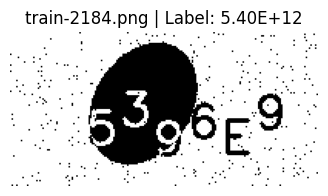

Before Fix:
image    train-2184.png
text           5.40E+12
Name: 2184, dtype: str
--------------------------------------------------------------------------------

After Fix:
image    train-2184.png
text             5396E9
Name: 2184, dtype: str


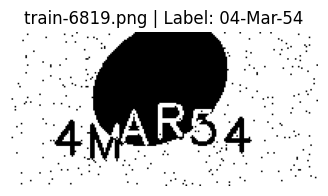

Before Fix:
image    train-6819.png
text          04-Mar-54
Name: 6819, dtype: str
--------------------------------------------------------------------------------

After Fix:
image    train-6819.png
text             4MAR56
Name: 6819, dtype: str


In [8]:
import cv2
import matplotlib.pyplot as plt
import os

bad_rows = train_labels[train_labels["text"].str.len() != 6]

for idx, row in bad_rows.iterrows():

    img_path = os.path.join(train_images_path, row["image"])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(4, 2))
    plt.imshow(img, cmap="gray")
    plt.title(f"{row['image']} | Label: {row['text']}")
    plt.axis("off")
    plt.show()

    print("Before Fix:")
    print(row)
    print("-" * 80)

    # Manually inspect image and enter correct label
    corrected_text = input(
        f"Enter corrected label for {row['image']} (current: {row['text']}): "
    )

    train_labels.loc[idx, "text"] = corrected_text

    print("\nAfter Fix:")
    print(train_labels.loc[idx])
    print("=" * 80)

## Sample Visualization

To gain an initial understanding of the dataset, a random subset of CAPTCHA images is visualized along with their corresponding labels. This qualitative inspection helps verify that the images have been loaded correctly and provides insight into the appearance, distortion patterns, character spacing, and overall complexity of the CAPTCHAs. Visualizing sample images is a useful exploratory step that helps identify potential preprocessing requirements and confirms the alignment between images and their labels.

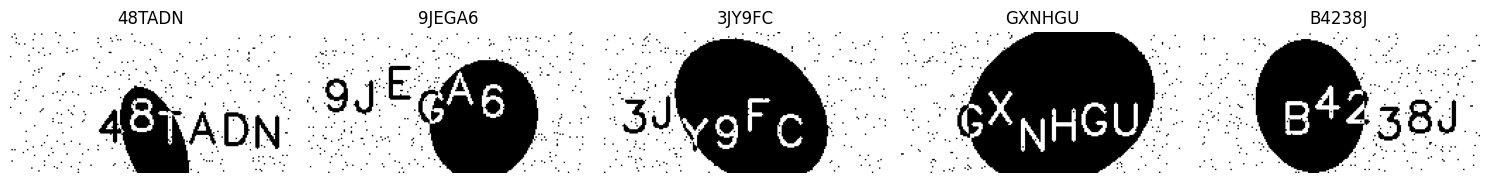

In [9]:
import cv2
import matplotlib.pyplot as plt
import os

sample_df = train_labels.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = cv2.imread(
        os.path.join(train_images_path, row['image']),
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(img, cmap='gray')
    ax.set_title(row['text'])
    ax.axis('off')

plt.tight_layout()
plt.show()

## Image Dimension Analysis

The dimensions of all training images are examined to verify consistency across the dataset. By extracting the height and width of each CAPTCHA image, it is possible to identify whether the dataset contains images of varying sizes or follows a standardized format. Consistent image dimensions simplify preprocessing and model design, as all samples can be fed into the neural network without requiring additional resizing or padding operations.

In [10]:
import os
import cv2

heights = []
widths = []

for img_name in train_labels['image']:
    img = cv2.imread(
        os.path.join(train_images_path, img_name),
        cv2.IMREAD_GRAYSCALE
    )

    h, w = img.shape

    heights.append(h)
    widths.append(w)

print(set(heights))
print(set(widths))

{100}
{200}


## Character Vocabulary Generation

After validating and cleaning the labels, a character vocabulary is constructed from all CAPTCHA texts in the training dataset. The process involves concatenating all labels and extracting the unique characters that appear across the dataset. This vocabulary represents the complete set of symbols that the model must recognize.

The resulting character set is used to create mappings between characters and numerical indices, enabling the conversion of text labels into encoded sequences for training. Similarly, these mappings are used during inference to decode the model's predictions back into human-readable CAPTCHA text.

In [11]:
all_text = ''.join(train_labels['text'])

vocab = sorted(set(all_text))

print("Vocabulary size:", len(vocab))
print(vocab)

Vocabulary size: 31
['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [12]:
train_labels['text'].str.len().value_counts().sort_index()

text
6    20000
Name: count, dtype: int64

## Training and Validation Split

To evaluate the model's performance on unseen data during training, the dataset is divided into training and validation sets using an 80:20 split. The training set is used to learn the model parameters, while the validation set provides an unbiased estimate of the model's generalization ability. The split is performed with a fixed random seed to ensure reproducibility, and the data is shuffled before splitting to maintain a representative distribution of CAPTCHA samples across both subsets.

In [13]:
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")

Train size: 16000
Val size: 4000


## Character Encoding

To enable training with neural networks, each character in the vocabulary is assigned a unique numerical index. Two mappings are created: `char2idx`, which converts characters to integers, and `idx2char`, which converts predicted indices back to characters. Since the model is trained using Connectionist Temporal Classification (CTC) loss, an additional blank token is reserved at index `0`. The total number of output classes is therefore equal to the number of unique characters plus one blank class required by the CTC framework.

In [14]:
characters = sorted(set("".join(train_df["text"])))

char2idx = {
    char: idx + 1
    for idx, char in enumerate(characters)
}

idx2char = {
    idx + 1: char
    for idx, char in enumerate(characters)
}

CTC_BLANK = 0

num_classes = len(characters) + 1

print(num_classes)

32


In [15]:
sample = "BU522X"

encoded = [char2idx[c] for c in sample]

print(encoded)

[10, 26, 4, 1, 1, 29]


## Character Distribution Analysis

A frequency check is performed for visually similar characters such as `0`, `1`, `I`, `L`, and `O`. These characters are commonly confused in CAPTCHA recognition tasks due to their similar appearance. Examining their occurrence within the dataset helps identify potential sources of classification errors and provides insight into the level of ambiguity present in the training data.

In [16]:
for c in ["0", "1", "I", "L", "O"]:
    print(c, (train_df["text"].str.contains(c)).sum())

0 0
1 0
I 0
L 0
O 0


## Custom Dataset Class

A custom PyTorch `Dataset` class is implemented to efficiently load and preprocess CAPTCHA images during training. For each sample, the corresponding grayscale image is read from disk, optional image transformations are applied, and pixel values are normalized to the range \([0,1]\). The image is then converted into a tensor and reshaped to include a channel dimension.

The associated CAPTCHA text is encoded into a sequence of numerical indices using the previously defined character-to-index mapping. In addition, the length of each label sequence is stored, which is required for CTC-based training. The dataset returns a dictionary containing the image tensor, encoded label sequence, and label length, enabling seamless integration with PyTorch data loaders and the CRNN training pipeline.

In [17]:
class CaptchaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        char2idx,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.char2idx = char2idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:
            image = self.transform(
                image=image
            )["image"]

        image = image.astype(np.float32) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        text = row["text"]

        encoded = torch.tensor(
            [self.char2idx[c] for c in text],
            dtype=torch.long
        )

        label_length = torch.tensor(
            len(text),
            dtype=torch.long
        )

        return {
            "image": image,
            "label": encoded,
            "label_length": label_length
        }

## Custom Collate Function

Since the model is trained using CTC loss, label sequences are handled differently from traditional classification tasks. A custom collate function is used to combine individual samples into batches during data loading. The image tensors are stacked into a single batch tensor, while the encoded labels from all samples are concatenated into a single one-dimensional tensor. The length of each label sequence is also preserved and stored separately, allowing the CTC loss function to correctly determine the boundaries of individual labels within the concatenated sequence. This batching strategy is both memory-efficient and fully compatible with the CRNN-CTC training framework.

In [18]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):

    images = torch.stack(
        [item["image"] for item in batch]
    )

    labels = torch.cat(
        [item["label"] for item in batch]
    )

    label_lengths = torch.stack(
        [item["label_length"] for item in batch]
    )
    return {
        "images": images,
        "labels": labels,
        "label_lengths": label_lengths
    }

## Dataset Initialization

After defining the custom dataset class, separate dataset objects are created for the training and validation sets. Both datasets use the same image directory and character encoding scheme, ensuring consistent preprocessing across the entire pipeline. The training dataset is used for model optimization, while the validation dataset is reserved for monitoring performance on unseen samples during training. At this stage, no additional image augmentations or transformations are applied, allowing the model to learn directly from the original CAPTCHA images.

In [20]:
train_dataset = CaptchaDataset(
    dataframe=train_df,
    image_dir=train_images_path,
    char2idx=char2idx,
    transform=None
)

val_dataset = CaptchaDataset(
    dataframe=val_df,
    image_dir=train_images_path,
    char2idx=char2idx,
    transform=None
)

## Test Dataset Class

A separate dataset class is created for the test set, where ground-truth labels are not available. The class loads CAPTCHA images from the test directory, sorts them according to their numerical identifiers to maintain a consistent ordering, and applies the same preprocessing steps used for the training data. Each image is converted to grayscale, normalized to the range \([0,1]\), and transformed into a tensor with an explicit channel dimension. In addition to the processed image, the dataset returns the corresponding image filename, allowing model predictions to be matched with the correct test samples during inference and submission generation.

In [21]:
import re

class TestDataset(Dataset):

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir

        self.images = sorted(
            os.listdir(image_dir),
            key=lambda x: int(re.findall(r"\d+", x)[0])
        )

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image = cv2.imread(
            os.path.join(self.image_dir, image_name),
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:
            image = self.transform(image=image)["image"]

        image = image.astype(np.float32) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, image_name

## Data Loader Configuration

PyTorch DataLoaders are used to efficiently load and batch data during training and validation. A batch size of 64 is selected to balance computational efficiency and memory usage. The training data is shuffled at the beginning of each epoch to improve generalization and reduce the risk of learning order-specific patterns, while the validation data is loaded in a fixed order for consistent evaluation. The custom collate function is used to correctly batch images and CTC-formatted labels, and multiple worker processes are employed to speed up data loading.

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [23]:
test_dataset = TestDataset(
    test_images_path
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## Batch Verification and Data Inspection

Before training the model, several checks are performed to verify that the data pipeline is functioning correctly. A sample batch is retrieved from the training DataLoader to inspect the shapes of the image tensors, encoded labels, and label-length tensors, ensuring compatibility with the CRNN architecture and CTC loss function.

A subset of images from the batch is also visualized to confirm that the CAPTCHA images are being loaded and preprocessed correctly. Similarly, samples from the test DataLoader are inspected to verify the image dimensions and filename ordering.

Finally, summary statistics such as the minimum, maximum, and mean pixel values are examined to confirm that image normalization has been applied successfully and that the input data lies within the expected range. These validation steps help identify potential preprocessing or loading issues before the training process begins.

In [ ]:
batch = next(iter(train_loader))

print(batch["images"].shape)
print(batch["labels"].shape)
print(batch["label_lengths"].shape)

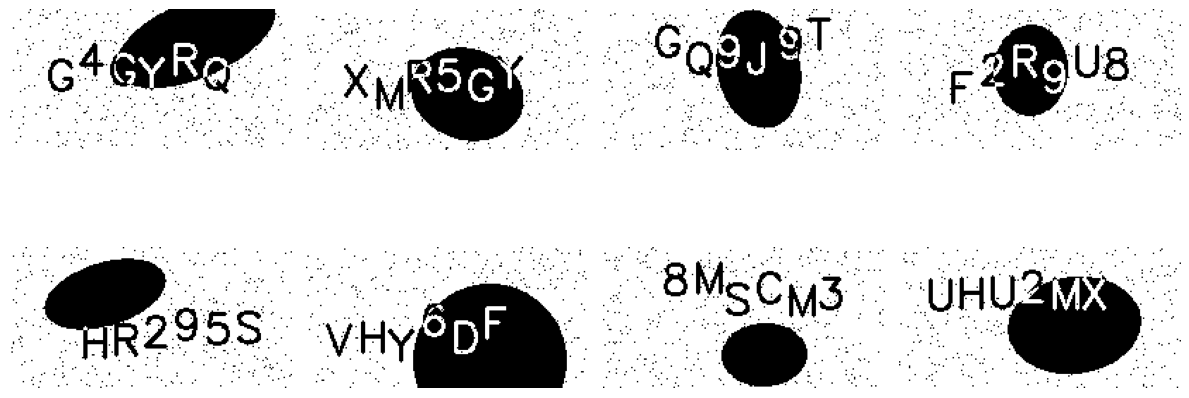

In [ ]:
batch = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):

    img = batch["images"][i].squeeze().numpy()

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
images, names = next(iter(test_loader))

print(images.shape)
print(names[:5])

torch.Size([64, 1, 100, 200])
('test-0.png', 'test-1.png', 'test-2.png', 'test-3.png', 'test-4.png')


In [27]:
batch = next(iter(train_loader))

print(
    batch["images"].min(),
    batch["images"].max(),
    batch["images"].mean()
)

tensor(0.) tensor(0.9412) tensor(0.6688)


## CRNN Architecture

The core of this project is a Convolutional Recurrent Neural Network (CRNN), a deep learning architecture specifically designed for image-based sequence recognition tasks such as OCR and CAPTCHA solving. The model combines convolutional layers for visual feature extraction with recurrent layers for sequence modeling, allowing it to recognize entire character sequences directly from an image.

The convolutional backbone consists of multiple convolution, batch normalization, ReLU activation, and pooling layers that progressively transform the input CAPTCHA image into a high-level feature representation. Pooling operations reduce the spatial dimensions while preserving important visual information, enabling the network to learn robust character features.

After feature extraction, the height dimension of the feature map is collapsed by averaging, converting the two-dimensional visual representation into a one-dimensional sequence. This sequence is then processed by two stacked Bidirectional Long Short-Term Memory (BiLSTM) layers, which capture contextual information from both left-to-right and right-to-left directions. Such bidirectional processing helps the model better understand dependencies between neighboring characters.

Finally, a fully connected classification layer projects the recurrent features into a probability distribution over all possible character classes, including the CTC blank token. The output sequence is then used with Connectionist Temporal Classification (CTC) loss, enabling the model to learn character sequences without requiring explicit character-level segmentation of the CAPTCHA images.

In [28]:
import torch
import torch.nn as nn


class CRNN(nn.Module):

    def __init__(
        self,
        num_classes,
        hidden_size=256
    ):
        super().__init__()

        self.cnn = nn.Sequential(

            # 100 x 200
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # 50 x 100
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # 25 x 50
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=(2, 1),
                stride=(2, 1)
            ),

            # 12 x 50
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=(2, 1),
                stride=(2, 1)
            ),

            # 6 x 50
            nn.Conv2d(512, 512, 2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)

        )

        self.lstm1 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )
        
        self.lstm2 = nn.LSTM(
            input_size=512,
            hidden_size=256,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(self, x):
    
        x = self.cnn(x)
    
        #print("CNN:", x.shape)
    
        x = x.mean(dim=2)
    
        #print("Mean:", x.shape)
    
        x = x.permute(0, 2, 1)
    
        #print("Permute:", x.shape)
    
        x, _ = self.lstm1(x)
    
        x, _ = self.lstm2(x)
    
        x = self.classifier(x)
    
        x = x.permute(1, 0, 2)
    
        return x

## Model Initialization

After defining the CRNN architecture, an instance of the model is created using the total number of output classes. The number of classes corresponds to the size of the character vocabulary plus one additional class reserved for the CTC blank token. Initializing the model at this stage constructs all convolutional, recurrent, and classification layers, preparing the network for training on the CAPTCHA recognition task.

In [29]:
NUM_CLASSES = len(characters) + 1

model = CRNN(
    num_classes=NUM_CLASSES
)

model

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel

## Model Summary

A detailed summary of the CRNN architecture is generated to inspect the dimensions of intermediate layers, parameter counts, and overall model complexity. This provides a clear overview of the network structure and helps verify that the architecture is configured correctly before training.

In [30]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 1, 100, 200)
)

Layer (type:depth-idx)                   Output Shape              Param #
CRNN                                     [49, 1, 32]               --
├─Sequential: 1-1                        [1, 512, 5, 49]           --
│    └─Conv2d: 2-1                       [1, 64, 100, 200]         640
│    └─BatchNorm2d: 2-2                  [1, 64, 100, 200]         128
│    └─ReLU: 2-3                         [1, 64, 100, 200]         --
│    └─MaxPool2d: 2-4                    [1, 64, 50, 100]          --
│    └─Conv2d: 2-5                       [1, 128, 50, 100]         73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 50, 100]         256
│    └─ReLU: 2-7                         [1, 128, 50, 100]         --
│    └─MaxPool2d: 2-8                    [1, 128, 25, 50]          --
│    └─Conv2d: 2-9                       [1, 256, 25, 50]          295,168
│    └─BatchNorm2d: 2-10                 [1, 256, 25, 50]          512
│    └─ReLU: 2-11                        [1, 256, 25, 50]          --
│ 

## Architecture Verification

Before training, a forward pass is performed to verify the dimensions of the intermediate feature maps and final model outputs. The output of the convolutional backbone is inspected to confirm that the spatial dimensions are reduced as expected and that the extracted features have the correct shape for sequence modeling.

A complete forward pass through the CRNN is then executed using a sample batch of images. The resulting output tensor is examined to ensure that the model produces a sequence of character probabilities with dimensions compatible with the CTC loss function. This verification step helps identify potential architectural or tensor-shape mismatches before the training process begins.

In [36]:
images = batch["images"].cuda()

with torch.no_grad():
    out = model(images)

print(out.shape)

torch.Size([49, 64, 32])


## Weight Initialization

To promote stable and efficient training, custom weight initialization is applied to all learnable layers of the CRNN. Different initialization strategies are chosen based on the characteristics of each layer type. Convolutional layers use Kaiming (He) initialization, which is well suited for ReLU activations and helps maintain healthy gradient flow in deep networks. Batch normalization layers are initialized with unit scaling factors and zero biases to preserve feature distributions at the start of training.

For the final classification layer, Xavier initialization is employed to balance the variance of activations across layers. The recurrent BiLSTM layers use Xavier initialization for input-to-hidden weights and orthogonal initialization for hidden-to-hidden weights, a common practice that improves training stability and helps preserve long-range dependencies. All bias terms are initialized to zero.

After initialization, summary statistics such as the mean and standard deviation of the classifier weights are inspected to verify that the parameters have been initialized correctly and are within a reasonable range before training begins.

In [37]:
import torch.nn as nn

def init_weights(m):

    # Convolution Layers
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(
            m.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        if m.bias is not None:
            nn.init.zeros_(m.bias)

    # BatchNorm Layers
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

    # Linear Layers
    elif isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

        if m.bias is not None:
            nn.init.zeros_(m.bias)

    # LSTM Layers
    elif isinstance(m, nn.LSTM):

        for name, param in m.named_parameters():

            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)

            elif "weight_hh" in name:
                nn.init.orthogonal_(param)

            elif "bias" in name:
                nn.init.zeros_(param)

In [38]:
model.apply(init_weights)

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel

In [39]:
print(model.classifier.weight.mean())
print(model.classifier.weight.std())

tensor(-3.4126e-05, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0610, device='cuda:0', grad_fn=<StdBackward0>)


## Loss Function and Optimizer

The model is trained using Connectionist Temporal Classification (CTC) loss, a sequence-learning objective that enables training without requiring explicit character-level segmentation of the CAPTCHA images. CTC aligns the predicted character probabilities with the target text sequences automatically, making it particularly well suited for OCR and CAPTCHA recognition tasks where character boundaries are not known beforehand. The blank token is assigned index `0`, and the `zero_infinity` option is enabled to prevent invalid loss values from disrupting training.

For optimization, the Adam optimizer is used with a learning rate of \(10^{-3}\). Adam combines adaptive learning rates with momentum-based updates, allowing the model to converge efficiently while handling the diverse parameter distributions present in convolutional and recurrent layers.

A sample batch is then extracted from the training DataLoader, providing image tensors, encoded labels, and label lengths that are used to verify the training pipeline and perform initial forward-pass experiments before full-scale training.

In [40]:
import torch.nn as nn

criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

In [41]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [42]:
batch = next(iter(train_loader))

images = batch["images"]
labels = batch["labels"]
label_lengths = batch["label_lengths"]

## CTC Loss Verification

Before starting the training process, a sample forward pass is performed to verify the compatibility of the model outputs with the CTC loss function. The CRNN generates a sequence of logits representing character predictions at each timestep. These logits are converted into log probabilities using the log-softmax operation, as required by the CTC objective.

The sequence length of the model output is used to construct the input-length tensor, which specifies the number of timesteps available for each sample in the batch. Together with the concatenated target labels and their corresponding lengths, these tensors are passed to the CTC loss function to compute an initial loss value.

The shapes of the logits, log probabilities, target labels, input lengths, and label lengths are then inspected to ensure that all dimensions conform to the requirements of CTC training. This verification step confirms that the model architecture, data pipeline, and loss function are correctly integrated before commencing full-scale optimization.

In [49]:
images = batch["images"].to(device)

with torch.no_grad():
    logits = model(images)

print(logits.shape)

torch.Size([49, 64, 32])


In [50]:
log_probs = logits.log_softmax(2)

In [51]:
T = logits.size(0)

input_lengths = torch.full(
    size=(images.size(0),),
    fill_value=T,
    dtype=torch.long
)

In [52]:
loss = criterion(
    log_probs,
    labels,
    input_lengths,
    label_lengths
)

print(loss)

tensor(23.9017, device='cuda:0')


In [53]:
print(log_probs.shape)
print(labels.shape)
print(input_lengths.shape)
print(label_lengths.shape)

torch.Size([49, 64, 32])
torch.Size([384])
torch.Size([64])
torch.Size([64])


In [54]:
torch.backends.cudnn.benchmark = True

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


## Training Function

A dedicated training function is implemented to perform one complete training epoch. During each iteration, a batch of images, encoded labels, and label lengths is transferred to the target device and passed through the CRNN to generate character predictions. The output logits are converted to log probabilities and used to compute the CTC loss by combining the predicted sequences with the ground-truth labels and their corresponding lengths.

The optimizer gradients are reset at the beginning of each iteration, after which backpropagation is performed to compute parameter gradients. The optimizer then updates the model weights based on these gradients. The training loss for each batch is accumulated throughout the epoch, and the average loss across all batches is returned as a measure of the model's training performance for that epoch.

In [55]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for batch in loader:

        images = batch["images"].to(device)
        labels = batch["labels"].to(device)
        label_lengths = batch["label_lengths"].to(device)

        optimizer.zero_grad()

        logits = model(images)

        log_probs = logits.log_softmax(2)

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=logits.size(0),
            dtype=torch.long,
            device=device
        )

        loss = criterion(
            log_probs,
            labels,
            input_lengths,
            label_lengths
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(loader)

    return epoch_loss

## Validation Function

To monitor the model's generalization performance, a separate validation function is implemented. The model is switched to evaluation mode, which disables training-specific behaviors and ensures consistent inference. Gradient computation is also turned off to reduce memory usage and improve computational efficiency during validation.

For each batch in the validation set, the images are passed through the CRNN to obtain character predictions. The logits are converted to log probabilities and evaluated using the same CTC loss function employed during training. The validation loss is accumulated across all batches and averaged at the end of the epoch.

Tracking validation loss alongside training loss provides an estimate of how well the model performs on unseen data and helps identify issues such as overfitting or underfitting during the training process.

In [56]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for batch in loader:

            images = batch["images"].to(device)
            labels = batch["labels"].to(device)
            label_lengths = batch["label_lengths"].to(device)

            logits = model(images)

            log_probs = logits.log_softmax(2)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(0),
                dtype=torch.long,
                device=device
            )

            loss = criterion(
                log_probs,
                labels,
                input_lengths,
                label_lengths
            )

            running_loss += loss.item()

    epoch_loss = running_loss / len(loader)

    return epoch_loss

In [57]:
print(
    sum(p.numel() for p in model.parameters())
)

8723616


## Model Training and Checkpointing

The CRNN is trained for 20 epochs using the previously defined training and validation procedures. During each epoch, the model parameters are updated using the training set, while performance on the validation set is evaluated to assess generalization. Both training and validation losses are recorded and displayed, providing insight into the learning progress of the network over time.

To preserve the best-performing model, a checkpointing strategy is employed based on validation loss. Whenever the validation loss improves, the model's parameters are saved to disk. This ensures that the final model corresponds to the epoch with the strongest validation performance rather than simply the last training epoch.

After training is complete, the saved checkpoint is reloaded and the model is switched to evaluation mode. This prepares the network for inference on unseen CAPTCHA images while ensuring that the optimal set of learned parameters is used for prediction

In [58]:
EPOCHS = 20

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_crnn.pth"
        )

        print("Model Saved")

Epoch [1/20] Train Loss: 3.7823 Val Loss: 3.5893
Model Saved
Epoch [2/20] Train Loss: 3.3687 Val Loss: 3.1116
Model Saved
Epoch [3/20] Train Loss: 2.5985 Val Loss: 2.3767
Model Saved
Epoch [4/20] Train Loss: 1.5625 Val Loss: 1.2787
Model Saved
Epoch [5/20] Train Loss: 0.5364 Val Loss: 0.1429
Model Saved
Epoch [6/20] Train Loss: 0.0733 Val Loss: 0.1072
Model Saved
Epoch [7/20] Train Loss: 0.0362 Val Loss: 0.0912
Model Saved
Epoch [8/20] Train Loss: 0.0339 Val Loss: 0.0986
Epoch [9/20] Train Loss: 0.0175 Val Loss: 0.3218
Epoch [10/20] Train Loss: 0.0204 Val Loss: 0.1115
Epoch [11/20] Train Loss: 0.0103 Val Loss: 0.0307
Model Saved
Epoch [12/20] Train Loss: 0.0138 Val Loss: 0.1633
Epoch [13/20] Train Loss: 0.0241 Val Loss: 0.0499
Epoch [14/20] Train Loss: 0.0142 Val Loss: 0.0241
Model Saved
Epoch [15/20] Train Loss: 0.0063 Val Loss: 0.0048
Model Saved
Epoch [16/20] Train Loss: 0.0019 Val Loss: 0.0040
Model Saved
Epoch [17/20] Train Loss: 0.0012 Val Loss: 0.0051
Epoch [18/20] Train Loss: 0

In [59]:
model.load_state_dict(
    torch.load("best_crnn.pth")
)

model.eval()

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel

## Training Dynamics

To monitor the learning process, the training and validation losses are recorded after each epoch and visualized. These curves provide insight into the convergence behavior of the model and help identify potential issues such as overfitting or underfitting. A decreasing training and validation loss indicates successful learning, while a widening gap between the two may suggest reduced generalization performance.

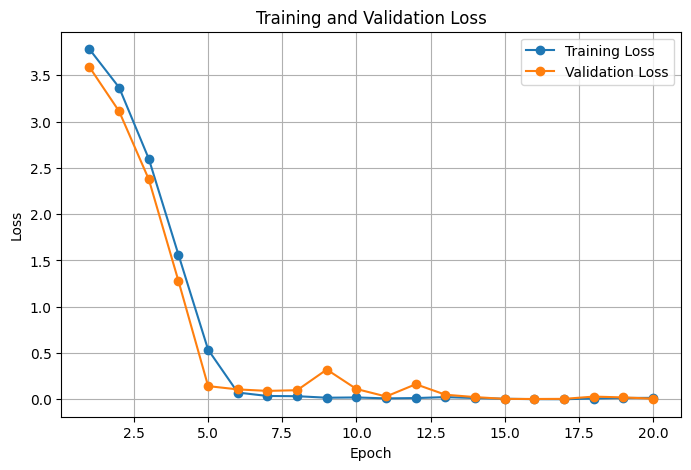

In [60]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Greedy CTC Decoding

After the CRNN generates character probabilities, a decoding step is required to convert the model outputs into readable CAPTCHA text. A greedy decoding strategy is used, where the character with the highest probability is selected at each timestep. This produces an initial sequence of predicted character indices.

Since the model is trained using CTC loss, the raw predictions may contain repeated characters and blank tokens. The decoder therefore applies the standard CTC post-processing procedure by first removing consecutive duplicate predictions and then discarding all blank symbols. The remaining character indices are mapped back to their corresponding characters using the index-to-character dictionary, producing the final predicted CAPTCHA string.

Greedy decoding is computationally efficient and serves as a simple yet effective inference method for sequence recognition tasks. Although more advanced approaches such as beam search can sometimes improve accuracy, greedy decoding is often sufficient for CAPTCHA recognition and provides fast prediction times.

In [61]:
def greedy_decode(logits, idx2char):

    # [T, B, C] -> [T, B]
    pred_indices = logits.argmax(dim=2)

    pred_indices = pred_indices.cpu().numpy()

    predictions = []

    batch_size = pred_indices.shape[1]

    for b in range(batch_size):

        sequence = pred_indices[:, b]

        decoded = []
        prev = None

        for idx in sequence:

            # Remove repeats
            if idx == prev:
                continue

            # Skip CTC blank
            if idx != 0:
                decoded.append(idx2char[idx])

            prev = idx

        predictions.append("".join(decoded))

    return predictions

## Test Set Inference

Once training is complete, the best-performing CRNN model is used to generate predictions for the unseen test images. The model is switched to evaluation mode and gradient computation is disabled to improve inference efficiency. Test images are processed in batches and passed through the network to obtain character probability sequences.

The predicted outputs are then converted into readable CAPTCHA text using the greedy CTC decoder. For each test image, the corresponding filename and decoded prediction are stored. After all test samples have been processed, the results are compiled into a Pandas DataFrame containing the image identifiers and their predicted CAPTCHA strings, forming the basis for the final submission file.

In [62]:
filenames = []
predictions = []

model.eval()

with torch.no_grad():

    for images, image_names in test_loader:

        images = images.to(device)

        logits = model(images)

        batch_preds = greedy_decode(
            logits,
            idx2char
        )

        filenames.extend(image_names)
        predictions.extend(batch_preds)

In [63]:
submission = pd.DataFrame({
    "image": filenames,
    "prediction": predictions
})

## Prediction Visualization

To qualitatively assess the model's performance, a random subset of test images is selected and displayed alongside their predicted CAPTCHA text. This visual inspection provides an intuitive way to evaluate the accuracy and consistency of the model's predictions on unseen data. By comparing the appearance of the CAPTCHA images with the generated outputs, potential strengths and failure cases of the CRNN can be identified beyond what quantitative metrics alone reveal.

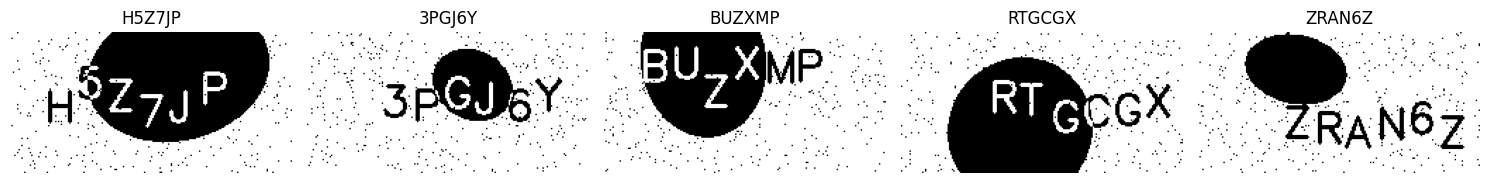

In [64]:
import random
import cv2
import matplotlib.pyplot as plt
import os

sample_indices = random.sample(
    range(len(submission)),
    5
)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, idx in zip(axes, sample_indices):

    image_name = submission.iloc[idx]["image"]
    prediction = submission.iloc[idx]["prediction"]

    img = cv2.imread(
        os.path.join(test_images_path, image_name),
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(img, cmap="gray")
    ax.set_title(prediction)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [65]:
submission

,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2
...,...,...
4995,test-4995.png,R5ENAF
4996,test-4996.png,WNQH33
4997,test-4997.png,9SYANQ
4998,test-4998.png,9X7DDR


In [66]:
submission.to_csv(
    "submission.csv",
    index=False
)

## Character Error Rate (CER) Evaluation

To quantitatively evaluate the quality of the model's predictions, the Character Error Rate (CER) metric is implemented. CER measures the proportion of characters that are incorrectly predicted and is widely used in OCR and text recognition tasks. The metric is based on the Levenshtein distance, which computes the minimum number of character insertions, deletions, and substitutions required to transform a predicted string into the corresponding ground-truth text.

For each prediction-target pair, the Levenshtein distance is calculated and accumulated across the dataset. The total edit distance is then divided by the total number of ground-truth characters, yielding the Character Error Rate. A lower CER indicates better recognition performance, with a value of zero corresponding to perfect character-level predictions. This metric provides a more informative evaluation than simple sequence accuracy, as it accounts for partial errors within predicted CAPTCHA strings.

In [67]:
def levenshtein_distance(s1, s2):

    m = len(s1)
    n = len(s2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):

            cost = 0 if s1[i-1] == s2[j-1] else 1

            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )

    return dp[m][n]

In [68]:
def compute_cer(predictions, targets):

    total_distance = 0
    total_chars = 0

    for pred, target in zip(predictions, targets):

        total_distance += levenshtein_distance(
            pred,
            target
        )

        total_chars += len(target)

    return total_distance / total_chars

## Validation Set Prediction Generation

To evaluate recognition performance, predictions are generated for the entire validation set using the trained CRNN model. During inference, the model processes each batch of validation images and produces character probability sequences, which are converted into readable text using the greedy CTC decoder.

At the same time, the ground-truth CAPTCHA labels are reconstructed from their encoded numerical representations. Since the labels are stored as concatenated sequences for CTC training, the corresponding label lengths are used to correctly separate and decode each target string. The predicted texts and ground-truth labels are then collected into separate lists, creating a complete set of prediction-target pairs that can be used for computing evaluation metrics such as Character Error Rate (CER) and sequence-level accuracy.

In [69]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for batch in val_loader:

        images = batch["images"].to(device)

        logits = model(images)

        preds = greedy_decode(
            logits,
            idx2char
        )

        all_preds.extend(preds)

        batch_size = images.size(0)

        labels = batch["labels"].cpu().numpy()

        label_lengths = batch["label_lengths"].cpu().numpy()

        start = 0

        for length in label_lengths:

            target_indices = labels[start:start+length]

            target_text = "".join(
                idx2char[idx]
                for idx in target_indices
            )

            all_targets.append(target_text)

            start += length

## Model Evaluation using Character Error Rate

After generating predictions for the validation set, the Character Error Rate (CER) is computed to assess the model's recognition performance. CER measures the proportion of character-level errors by comparing the predicted CAPTCHA strings with their corresponding ground-truth labels. It is calculated as the total Levenshtein edit distance divided by the total number of characters in the target texts.

A lower CER indicates better performance, as fewer character insertions, deletions, and substitutions are required to transform the predictions into the correct labels. This metric provides a detailed evaluation of OCR quality and helps quantify the effectiveness of the CRNN in recognizing CAPTCHA sequences.

In [70]:
cer = compute_cer(
    all_preds,
    all_targets
)

print(f"CER: {cer:.6f}")

CER: 0.000667


## Sequence-Level Accuracy

In addition to Character Error Rate (CER), sequence-level accuracy is computed to measure the percentage of CAPTCHA images that are recognized perfectly. A prediction is considered correct only when the entire predicted string exactly matches the corresponding ground-truth label. Even a single incorrect character causes the prediction to be counted as incorrect.

Sequence accuracy provides a stricter evaluation than CER and is particularly relevant for CAPTCHA recognition, where the objective is typically to recover the complete text sequence without errors. The metric is calculated as the ratio of exactly correct predictions to the total number of validation samples, offering a direct measure of the model's end-to-end recognition performance.

In [71]:
correct = sum(
    p == t
    for p, t in zip(all_preds, all_targets)
)

accuracy = correct / len(all_targets)

print(f"Sequence Accuracy: {accuracy:.4%}")

Sequence Accuracy: 99.6250%


## Character-wise Error Analysis

To better understand the model's mistakes, prediction errors are analyzed at the character level. For each incorrectly predicted CAPTCHA, mismatched characters are identified and counted. This analysis helps reveal systematic confusions between visually similar characters, such as `0` and `O` or `1` and `I`, and provides insight into the specific recognition challenges faced by the model. Understanding these error patterns can guide future improvements in model architecture, training data, or preprocessing techniques.

In [72]:
from collections import Counter
import pandas as pd

confusions = Counter()

for pred, target in zip(all_preds, all_targets):

    min_len = min(len(pred), len(target))

    # Count substitutions
    for p, t in zip(pred[:min_len], target[:min_len]):
        if p != t:
            confusions[(t, p)] += 1

    # Count deletions
    if len(target) > len(pred):
        for t in target[min_len:]:
            confusions[(t, "<missing>")] += 1

    # Count insertions
    elif len(pred) > len(target):
        for p in pred[min_len:]:
            confusions[("<extra>", p)] += 1

top_confusions = pd.DataFrame(
    [
        {
            "Ground Truth": gt,
            "Predicted": pred,
            "Count": count
        }
        for (gt, pred), count in confusions.most_common(15)
    ]
)

top_confusions

,Ground Truth,Predicted,Count
0,7,<missing>,3
1,G,C,2
2,U,<missing>,2
3,R,P,1
4,R,<missing>,1
5,4,<missing>,1
6,P,E,1
7,E,<missing>,1
8,C,U,1
9,P,S,1


## Error Analysis and Feature Map Extraction

To better understand the behavior of the CRNN, an error analysis step is performed by comparing the predicted CAPTCHA strings with their corresponding ground-truth labels. All incorrectly recognized samples are identified and displayed, making it possible to observe common failure patterns, character confusions, and challenging CAPTCHA instances. This qualitative analysis helps reveal weaknesses of the model that may not be immediately apparent from aggregate evaluation metrics.

In addition, feature map visualization is prepared using forward hooks registered on the convolutional layers of the network. These hooks capture intermediate activations generated during a forward pass, allowing the internal representations learned by the CNN backbone to be examined. By inspecting these feature maps, it becomes possible to understand how the model progressively transforms raw CAPTCHA images into higher-level features that are later used by the recurrent layers for sequence recognition.

In [73]:
for pred, target in zip(all_preds, all_targets):

    if pred != target:
        print("GT  :", target)
        print("Pred:", pred)
        print("-" * 50)

GT  : HRQEW5
Pred: HPQEW5
--------------------------------------------------
GT  : CCNRRR
Pred: CCNRR
--------------------------------------------------
GT  : BMA444
Pred: BMA44
--------------------------------------------------
GT  : KV5777
Pred: KV577
--------------------------------------------------
GT  : WZGPPE
Pred: WZCPE
--------------------------------------------------
GT  : 363UUU
Pred: 363UU
--------------------------------------------------
GT  : XF9777
Pred: XF977
--------------------------------------------------
GT  : WBYCCU
Pred: WBYCU
--------------------------------------------------
GT  : 45C777
Pred: 45C77
--------------------------------------------------
GT  : 4ADPPS
Pred: 4ADPS
--------------------------------------------------
GT  : EAXPPP
Pred: EAXPP
--------------------------------------------------
GT  : D9MYYY
Pred: D9MYY
--------------------------------------------------
GT  : CK3GJH
Pred: CK3CJH
--------------------------------------------------
GT  : F6SG

In [74]:
image, _ = test_dataset[0]

image = image.unsqueeze(0).to(device)

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

In [75]:
for name, layer in model.cnn.named_children():

    layer.register_forward_hook(
        get_activation(
            f"{name}_{layer.__class__.__name__}"
        )
    )

## Feature Map Visualization

To gain insight into the internal workings of the CNN backbone, intermediate feature maps are extracted and visualized using the activations captured through forward hooks. A sample CAPTCHA image is passed through the network, and the output of each convolutional block is recorded for analysis.

The feature maps from the early convolutional layers are first examined individually. These layers typically learn low-level visual features such as edges, contours, character strokes, and texture patterns. As the image progresses through deeper layers of the network, the feature representations become increasingly abstract, focusing on higher-level structures and character-specific patterns that are relevant for text recognition.

To observe this progression, activations from multiple stages of the CNN are visualized and compared. Additional visualizations are generated for all recorded layers, displaying representative feature channels alongside their corresponding tensor shapes. This analysis provides a qualitative understanding of how the CRNN transforms raw CAPTCHA images into discriminative feature representations that enable accurate sequence recognition by the subsequent BiLSTM layers.

In [76]:
model.eval()

with torch.no_grad():
    _ = model(image)

In [77]:
for name, act in activations.items():
    print(name, act.shape)

0_Conv2d torch.Size([1, 64, 100, 200])
1_BatchNorm2d torch.Size([1, 64, 100, 200])
2_ReLU torch.Size([1, 64, 100, 200])
3_MaxPool2d torch.Size([1, 64, 50, 100])
4_Conv2d torch.Size([1, 128, 50, 100])
5_BatchNorm2d torch.Size([1, 128, 50, 100])
6_ReLU torch.Size([1, 128, 50, 100])
7_MaxPool2d torch.Size([1, 128, 25, 50])
8_Conv2d torch.Size([1, 256, 25, 50])
9_BatchNorm2d torch.Size([1, 256, 25, 50])
10_ReLU torch.Size([1, 256, 25, 50])
11_Conv2d torch.Size([1, 256, 25, 50])
12_BatchNorm2d torch.Size([1, 256, 25, 50])
13_ReLU torch.Size([1, 256, 25, 50])
14_MaxPool2d torch.Size([1, 256, 12, 50])
15_Conv2d torch.Size([1, 512, 12, 50])
16_BatchNorm2d torch.Size([1, 512, 12, 50])
17_ReLU torch.Size([1, 512, 12, 50])
18_Conv2d torch.Size([1, 512, 12, 50])
19_BatchNorm2d torch.Size([1, 512, 12, 50])
20_ReLU torch.Size([1, 512, 12, 50])
21_MaxPool2d torch.Size([1, 512, 6, 50])
22_Conv2d torch.Size([1, 512, 5, 49])
23_BatchNorm2d torch.Size([1, 512, 5, 49])
24_ReLU torch.Size([1, 512, 5, 49])


In [81]:
print(activations.keys())

dict_keys(['0_Conv2d', '1_BatchNorm2d', '2_ReLU', '3_MaxPool2d', '4_Conv2d', '5_BatchNorm2d', '6_ReLU', '7_MaxPool2d', '8_Conv2d', '9_BatchNorm2d', '10_ReLU', '11_Conv2d', '12_BatchNorm2d', '13_ReLU', '14_MaxPool2d', '15_Conv2d', '16_BatchNorm2d', '17_ReLU', '18_Conv2d', '19_BatchNorm2d', '20_ReLU', '21_MaxPool2d', '22_Conv2d', '23_BatchNorm2d', '24_ReLU'])


In [82]:
activations["0_Conv2d"].shape

torch.Size([1, 64, 100, 200])

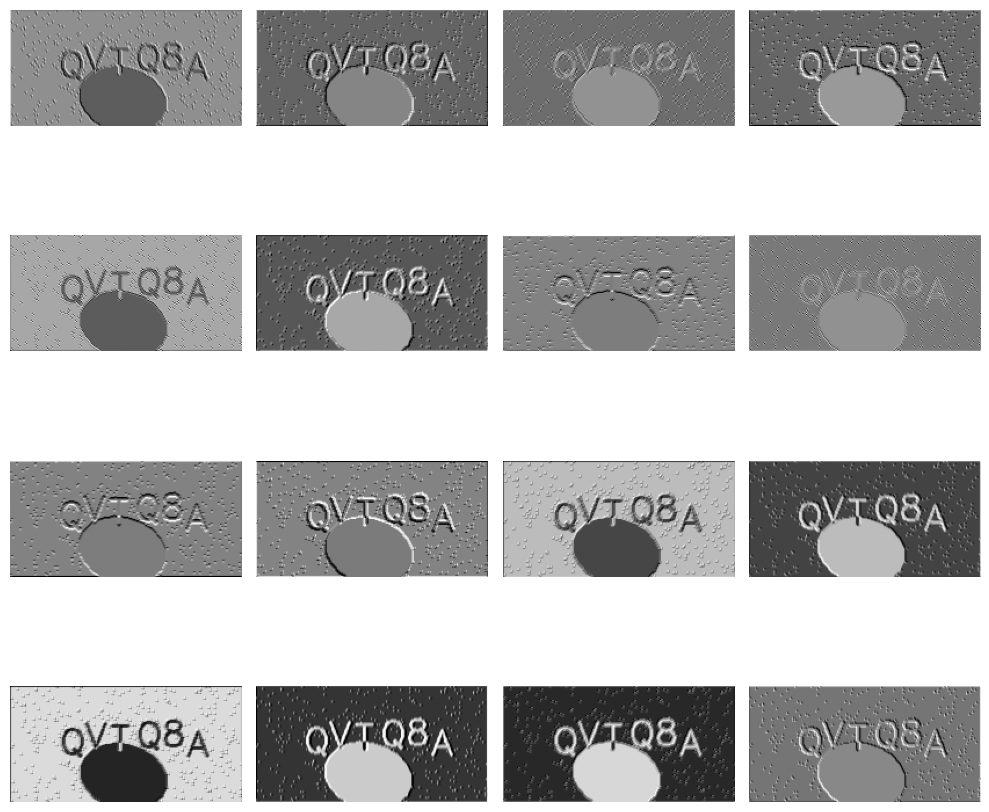

In [83]:
import matplotlib.pyplot as plt

feat = activations["0_Conv2d"][0]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feat[i],
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

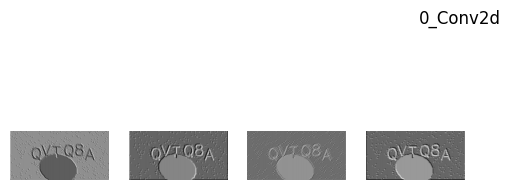

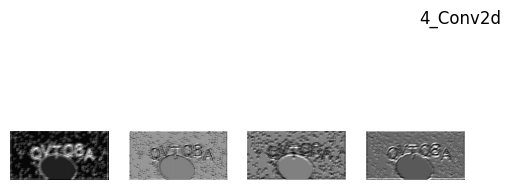

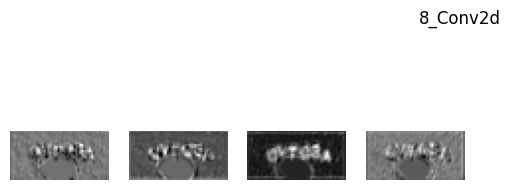

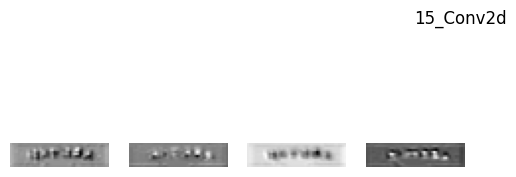

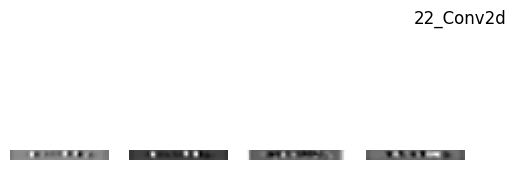

In [84]:
layers = [
    "0_Conv2d",
    "4_Conv2d",
    "8_Conv2d",
    "15_Conv2d",
    "22_Conv2d"
]

for layer in layers:

    feat = activations[layer][0]

    plt.figure(figsize=(12,3))

    for i in range(4):

        plt.subplot(1,8,i+1)
        plt.imshow(
            feat[i],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(layer)
    plt.show()

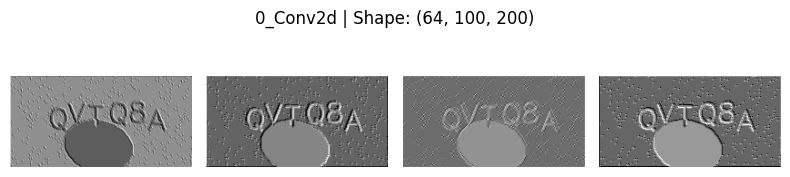

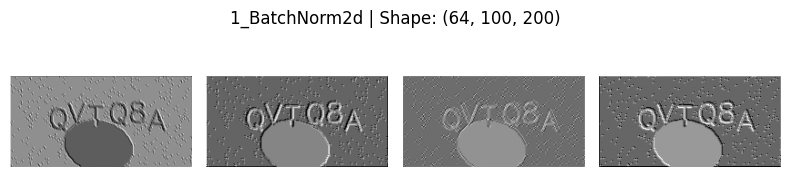

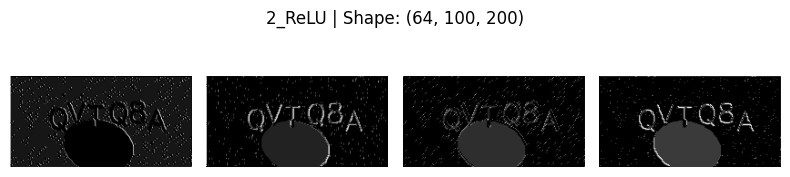

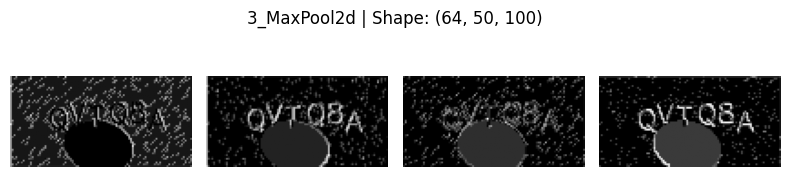

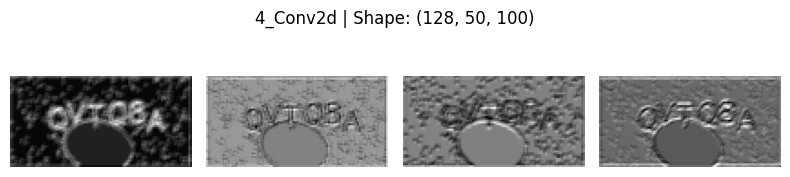

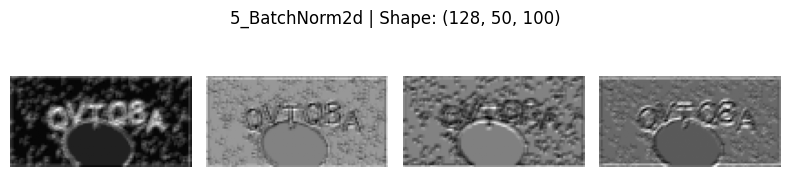

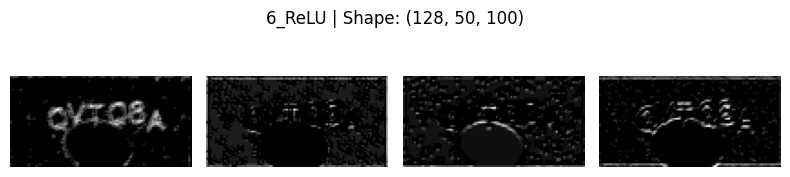

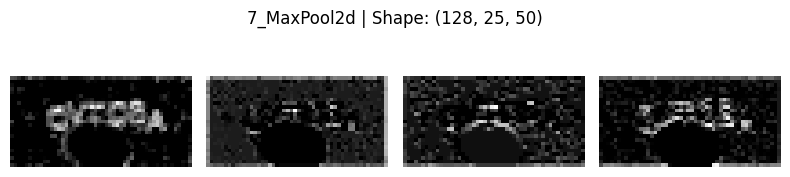

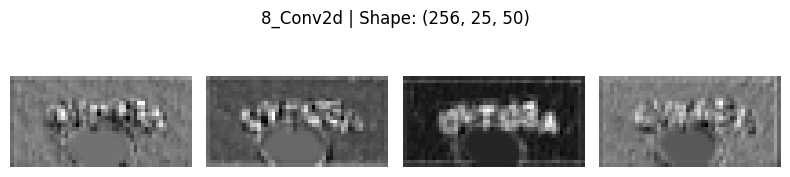

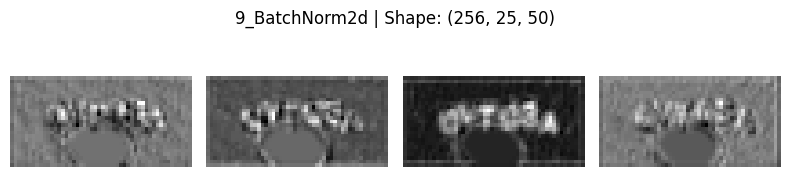

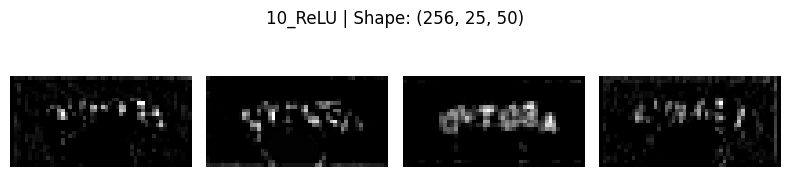

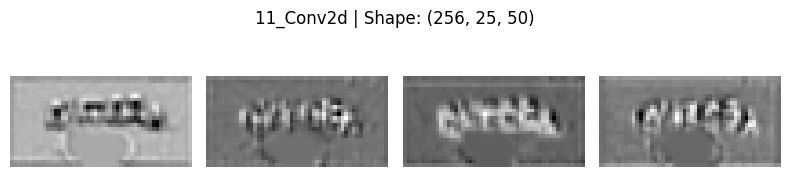

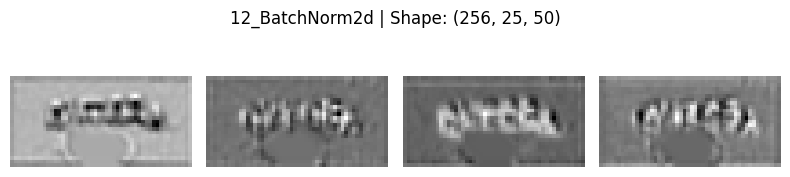

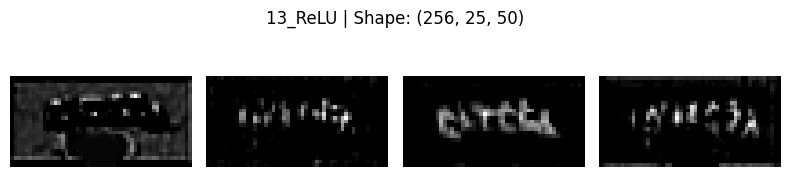

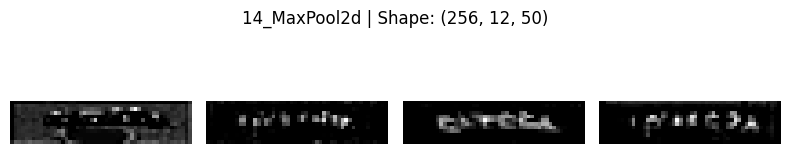

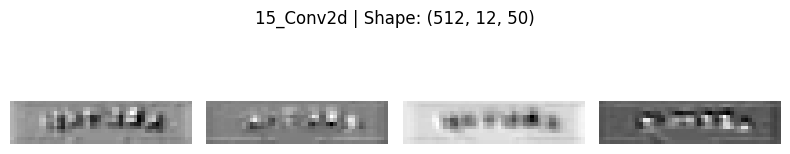

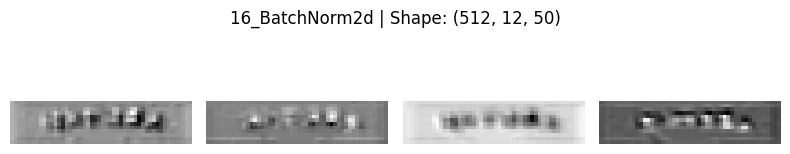

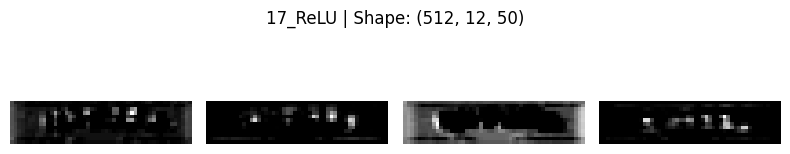

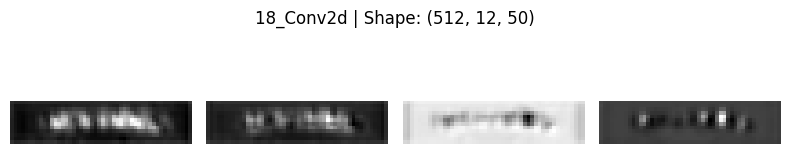

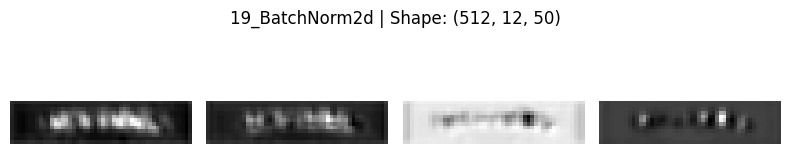

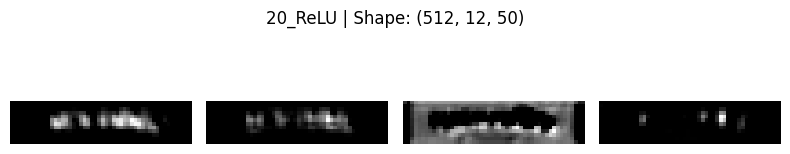

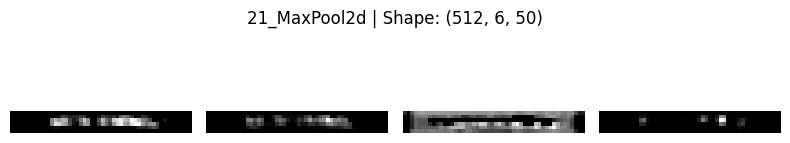

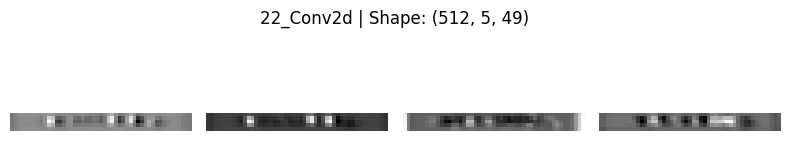

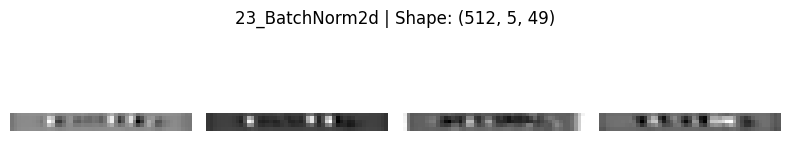

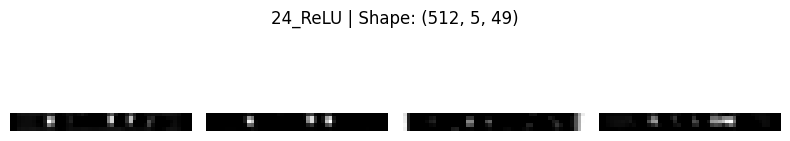

In [85]:
import matplotlib.pyplot as plt

for name, feat in activations.items():

    feat = feat[0]  # remove batch dimension

    plt.figure(figsize=(8, 2))

    for i in range(4):

        plt.subplot(1, 4, i + 1)

        plt.imshow(
            feat[i],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"{name} | Shape: {tuple(feat.shape)}"
    )

    plt.tight_layout()
    plt.show()

## Sequence Feature Analysis

Beyond visualizing convolutional feature maps, the intermediate sequence representation produced by the CNN backbone is also examined. After the final convolutional layer, the height dimension of the feature map is collapsed through global averaging, transforming the two-dimensional feature representation into a sequence of feature vectors. This sequence forms the input to the BiLSTM layers and represents how the model interprets the CAPTCHA image as a series of character-related features along the horizontal axis.

To better understand this representation, the resulting feature matrix is visualized as a heatmap, where each column corresponds to a sequence position and each row represents a learned feature channel. The heatmap provides an intuitive view of how information is distributed across the sequence before recurrent processing.

To further investigate the role of the recurrent layers, a feature extraction method is introduced to capture both the CNN-generated sequence features and the final BiLSTM outputs. By examining these intermediate representations, it becomes possible to study how contextual information is incorporated across sequence positions and how the recurrent network refines visual features into representations suitable for character recognition. This analysis offers valuable insight into the interaction between the convolutional and recurrent components of the CRNN architecture.

In [86]:
with torch.no_grad():

    x = model.cnn(image)

    print(x.shape)

torch.Size([1, 512, 5, 49])


In [87]:
x = x.mean(dim=2)

print(x.shape)

torch.Size([1, 512, 49])


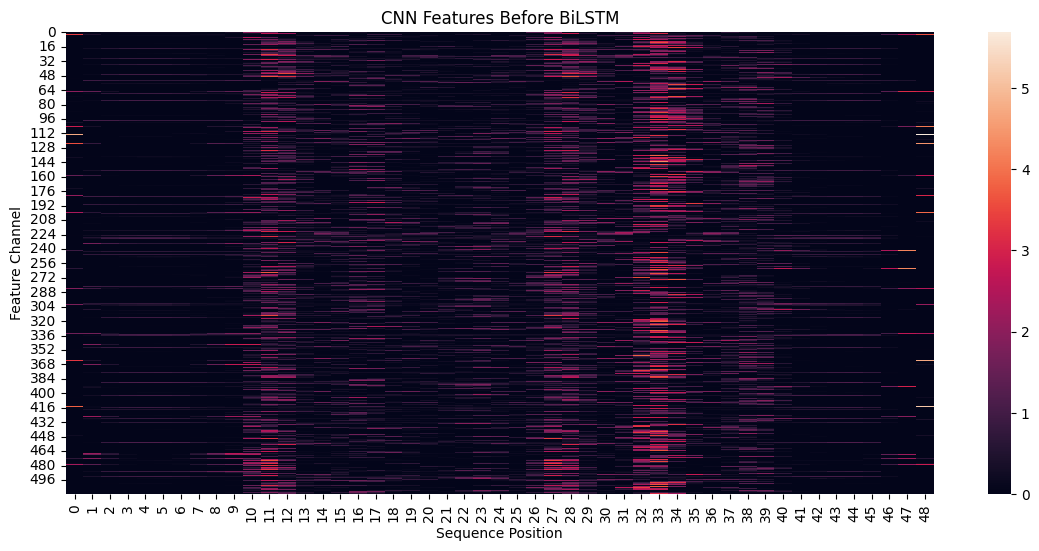

In [88]:
import seaborn as sns

feat = x.squeeze(0).cpu().numpy()

plt.figure(figsize=(14,6))

sns.heatmap(feat)

plt.title("CNN Features Before BiLSTM")
plt.xlabel("Sequence Position")
plt.ylabel("Feature Channel")

plt.show()

In [89]:
def get_features(self, x):

    cnn_features = self.cnn(x)

    cnn_features = cnn_features.mean(dim=2)

    # [B, 512, 49]

    lstm_input = cnn_features.permute(0, 2, 1)

    # [B, 49, 512]

    lstm1_out, _ = self.lstm1(lstm_input)

    lstm2_out, _ = self.lstm2(lstm1_out)

    return cnn_features, lstm2_out

In [91]:
model.eval()

with torch.no_grad():

    cnn_features = model.cnn(image)

    cnn_features = cnn_features.mean(dim=2)

    lstm_input = cnn_features.permute(0, 2, 1)

    lstm1_out, _ = model.lstm1(lstm_input)

    lstm_features, _ = model.lstm2(lstm1_out)

## CNN and BiLSTM Feature Representation Comparison

To understand how the recurrent component enhances the model's representations, the feature sequences produced before and after the BiLSTM layers are compared. The CNN generates a sequence of high-dimensional feature vectors that capture local visual patterns from different regions of the CAPTCHA image. These features primarily encode appearance-based information such as character shapes, edges, and textures.

After passing through the stacked BiLSTM layers, the feature representation is transformed to incorporate contextual information from both past and future sequence positions. Unlike the CNN features, which are largely local in nature, the BiLSTM outputs encode dependencies across the entire character sequence, enabling the model to better distinguish visually similar characters and resolve ambiguities using surrounding context.

Heatmaps are used to visualize both representations, allowing differences in activation patterns to be observed across sequence positions. A side-by-side comparison highlights how the recurrent layers reorganize and enrich the feature space. Finally, the original CAPTCHA image is displayed alongside the CNN and BiLSTM feature heatmaps, providing a complete view of how visual information is progressively transformed from raw pixels into context-aware sequence representations suitable for text recognition.

In [92]:
cnn_features = cnn_features.squeeze(0).cpu().numpy()

# [512,49]

lstm_features = lstm_features.squeeze(0).cpu().numpy()

# [49,512]

lstm_features = lstm_features.T

# [512,49]

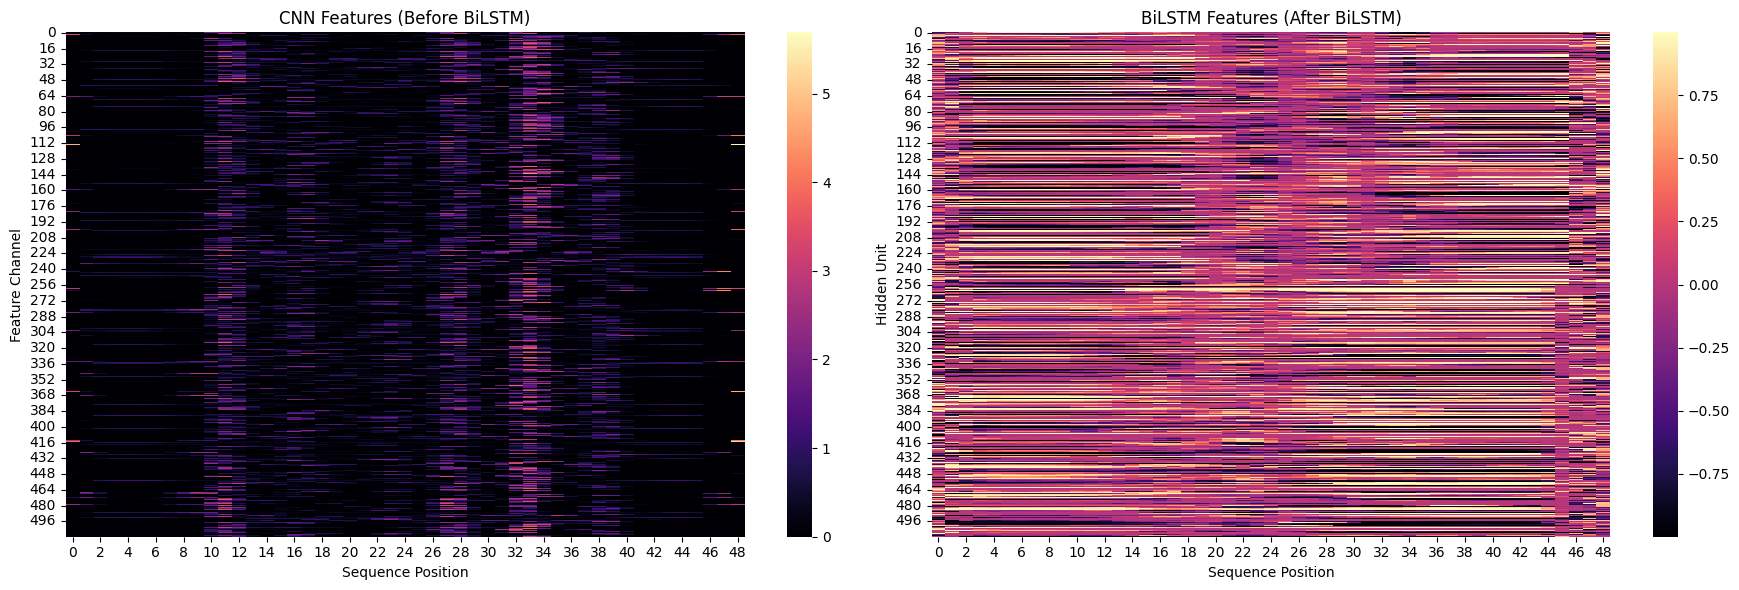

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6)
)

sns.heatmap(
    cnn_features,
    ax=axes[0],
    cmap="magma"
)

axes[0].set_title(
    "CNN Features (Before BiLSTM)"
)

axes[0].set_xlabel(
    "Sequence Position"
)

axes[0].set_ylabel(
    "Feature Channel"
)

sns.heatmap(
    lstm_features,
    ax=axes[1],
    cmap="magma"
)

axes[1].set_title(
    "BiLSTM Features (After BiLSTM)"
)

axes[1].set_xlabel(
    "Sequence Position"
)

axes[1].set_ylabel(
    "Hidden Unit"
)

plt.tight_layout()
plt.show()

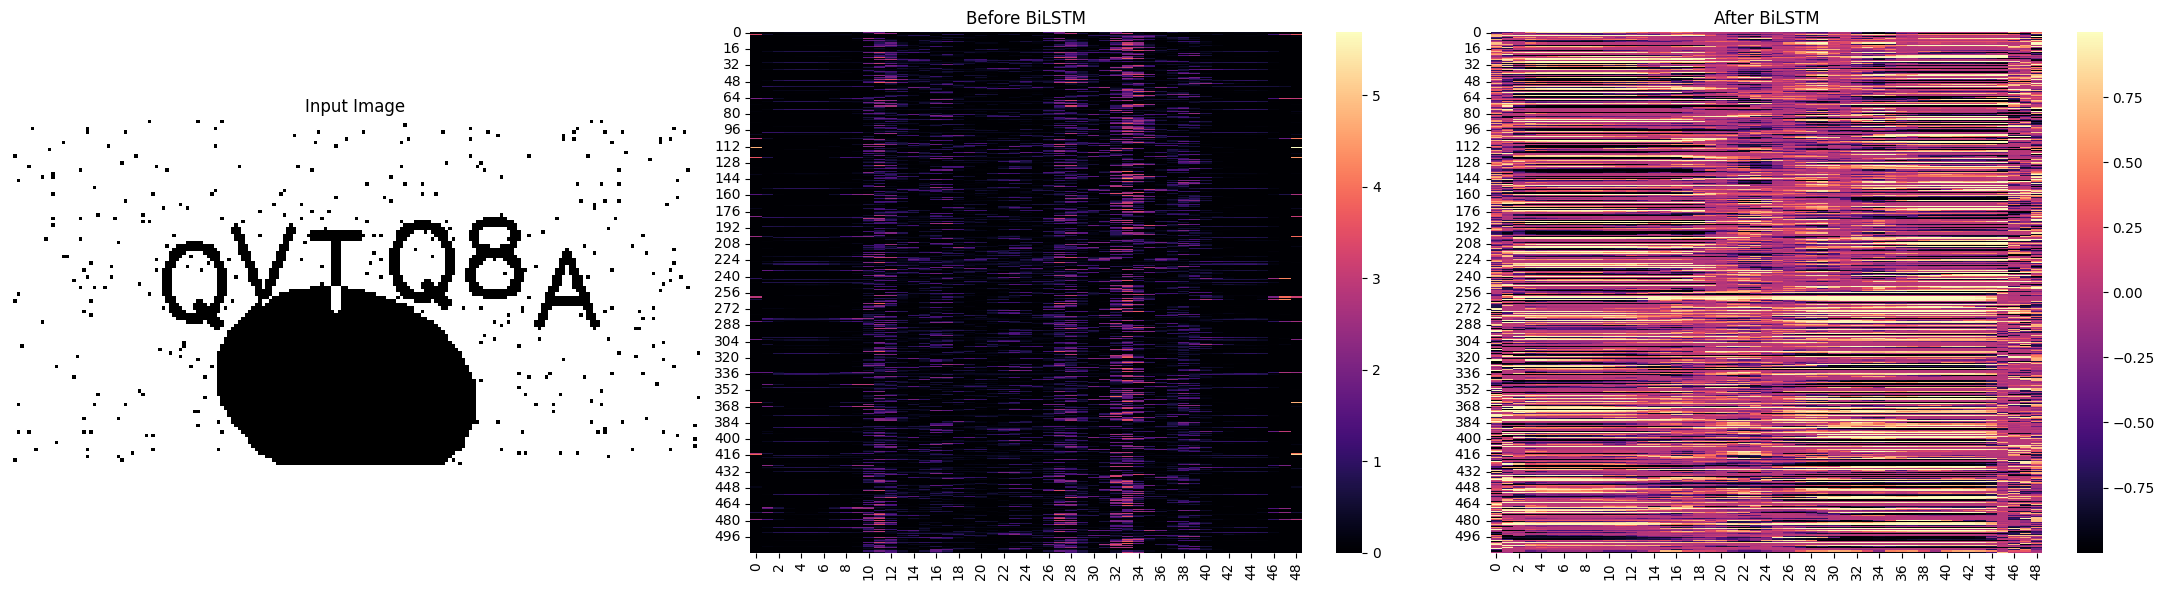

In [94]:
img = image.squeeze().cpu().numpy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6)
)

axes[0].imshow(
    img,
    cmap="gray"
)

axes[0].set_title("Input Image")
axes[0].axis("off")

sns.heatmap(
    cnn_features,
    ax=axes[1],
    cmap="magma"
)

axes[1].set_title(
    "Before BiLSTM"
)

sns.heatmap(
    lstm_features,
    ax=axes[2],
    cmap="magma"
)

axes[2].set_title(
    "After BiLSTM"
)

plt.tight_layout()
plt.show()

# Conclusion

In this project, a Convolutional Recurrent Neural Network (CRNN) was developed for CAPTCHA recognition by combining convolutional feature extraction with recurrent sequence modeling. The CNN backbone learned spatial representations from CAPTCHA images, while stacked Bidirectional LSTM layers captured contextual dependencies across character positions, enabling end-to-end sequence recognition without explicit character segmentation.

The workflow included data validation and cleaning, vocabulary construction, custom dataset and data loader implementation, CRNN architecture design, CTC-based training, and quantitative evaluation using Character Error Rate (CER) and sequence-level accuracy. In addition to performance evaluation, feature map visualizations and intermediate representation analysis were conducted to better understand how the model processes CAPTCHA images and transforms visual information into context-aware sequence features.

The results demonstrate the effectiveness of CRNNs for OCR-style tasks, particularly in scenarios where characters are distorted, connected, or difficult to segment individually. The project also highlights the importance of data quality, appropriate sequence modeling techniques, and model interpretability in building reliable text recognition systems.

Future improvements could include the use of more advanced CNN backbones such as ResNet or EfficientNet, beam-search decoding instead of greedy decoding, data augmentation strategies to improve robustness, and transformer-based sequence models that have recently achieved state-of-the-art performance in OCR applications.